In [16]:
import keypoint_moseq as kpms
import matplotlib.pyplot as plt
import os
from pathlib import Path
import numpy as np



In [ ]:
subject = '2209'
session = 't7'
modelFolder = "labels_v003_0.5scaling"
project_dir = str(Path(f"/Users/ramzyalmulla/research/smearlab/keypoint_moseq_{subject}_{session}/"))
config = lambda: kpms.load_config(project_dir)

base_path_str = "/Volumes/CrucialRZA/smearlab/clickbait-loco/thermister/"
sleap_dir = str(Path(f"{base_path_str}{modelFolder}/"))

# sleap_file = str(list(Path(sleap_dir).glob(f"**/*{subject}_{session}.slp"))[0])  # any .slp or .h5 file with predictions for a single video
sleap_file = str(list(Path(sleap_dir).glob(f"**/*{subject}_{session}.slp"))[0])  # any .slp or .h5 file with predictions for a single video

video_dir = str(Path(base_path_str+f"{subject}/{session.strip('_raw')}/"))  # any directory containing videos (e.g. .mp4, .avi) and/or sleap files with predictions for those videos
if not os.path.exists(project_dir):
    kpms.setup_project(project_dir, sleap_file=sleap_file,video_dir=video_dir) 

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = '/Volumes/CrucialRZA/smearlab/clickbait-loco/thermister/labels_v003_0.5scaling/preds/*t7.slp', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [7]:
# load data 
keypoint_data_path = sleap_file  # can be a file, a directory, or a list of files
coordinates, confidences, bodyparts = kpms.load_keypoints(keypoint_data_path, "sleap")

Loading keypoints: 100%|██████████████████| 1/1 [00:02<00:00,  2.04s/it]


In [8]:

kpms.update_config(project_dir,
                   use_bodyparts=['nose1','neck1','centroid1','forepawL1','forepawR1','hindpawL1','hindpawR1','tailstart1'],
                   anterior_bodyparts=["nose1","neck1"],posterior_bodyparts=["tailstart1"])

In [ ]:

coordinates, confidences = kpms.outlier_removal(
    coordinates,
    confidences,
    project_dir,
    overwrite=False,
    **config()
)


In [46]:
data, metadata = kpms.format_data(coordinates, confidences, **config())

In [8]:
# %matplotlib ipympl
# kpms.noise_calibration(project_dir, coordinates, confidences, **config())


>=90.0% of variance exlained by 7 components.


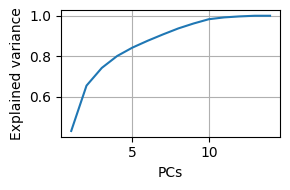

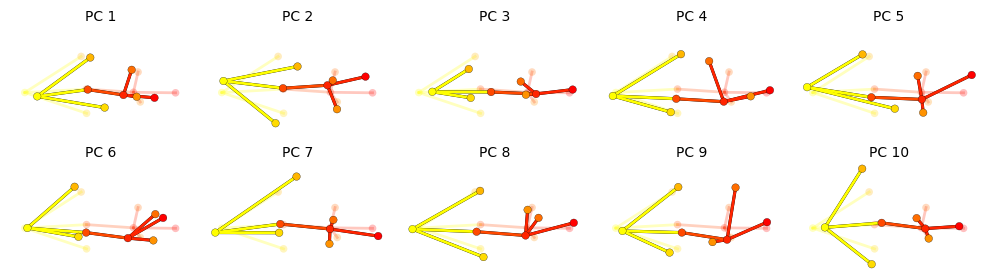

In [47]:
plt.close("all")
%matplotlib inline
pca = kpms.fit_pca(**data, **config())
kpms.save_pca(pca, project_dir)

kpms.print_dims_to_explain_variance(pca, 0.9)
kpms.plot_scree(pca, project_dir=project_dir)
kpms.plot_pcs(pca, project_dir=project_dir, **config())

# use the following to load an already fit model
# pca = kpms.load_pca(project_dir)

In [48]:
kpms.update_config(project_dir, latent_dim=7)

In [49]:
kpms.update_config(
    project_dir,
    sigmasq_loc=kpms.estimate_sigmasq_loc(data["Y"], data["mask"], filter_size=config()["fps"])
)

In [50]:
import jax_moseq
data = jax_moseq.utils.debugging.convert_data_precision(data)


In [58]:
# initialize the model
model = kpms.init_model(data, pca=pca, **config())

# # optionally modify kappa
model = kpms.update_hypparams(model, kappa=5e8)

Outputs will be saved to /Users/ramzyalmulla/research/smearlab/keypoin
t_moseq_2209_t7/2026_04_21-13_24_07


 49%|█████████████████▏                 | 25/51 [00:08<00:09,  2.78it/s]

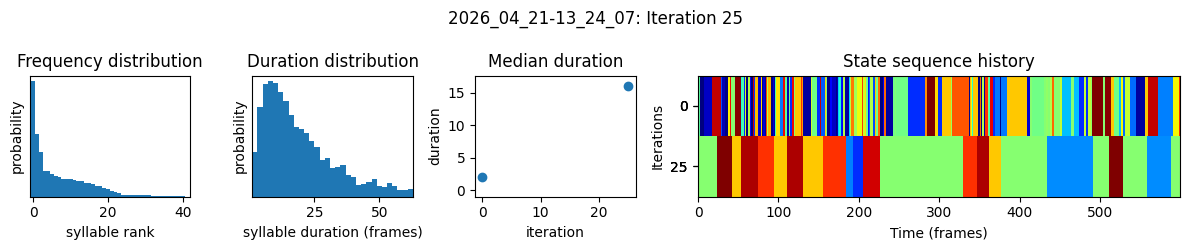

 98%|██████████████████████████████████▎| 50/51 [00:18<00:00,  2.88it/s]

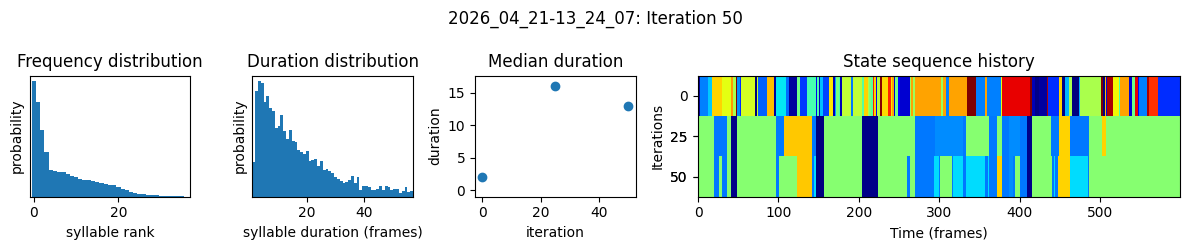

100%|███████████████████████████████████| 51/51 [00:18<00:00,  2.74it/s]


In [59]:
num_ar_iters = 50

model, model_name = kpms.fit_model(
    model, data, metadata, project_dir, jitter=1e-2,ar_only=True, num_iters=num_ar_iters
)

Outputs will be saved to /Users/ramzyalmulla/research/smearlab/keypoin
t_moseq_2209_t7/2026_04_21-13_24_07


  5%|█▌                                | 25/551 [00:53<18:25,  2.10s/it]

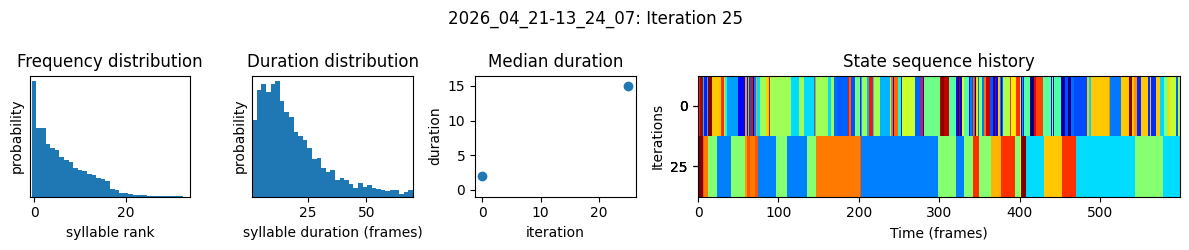

  9%|███                               | 50/551 [01:45<17:29,  2.09s/it]

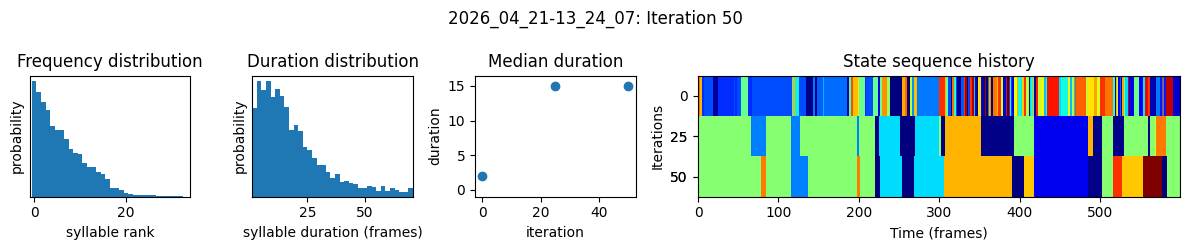

 14%|████▋                             | 75/551 [02:38<16:31,  2.08s/it]

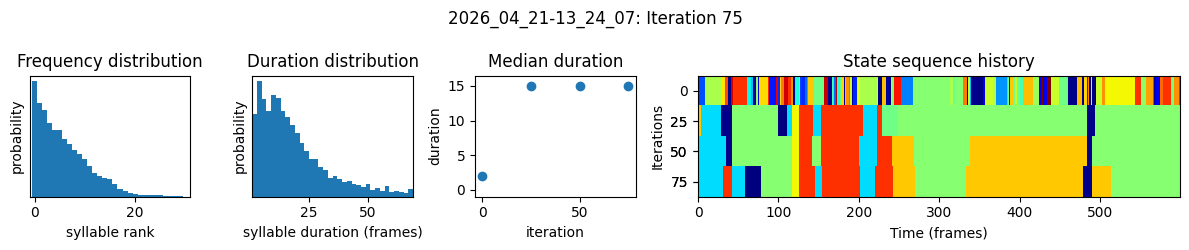

 18%|█████▉                           | 100/551 [03:31<15:43,  2.09s/it]

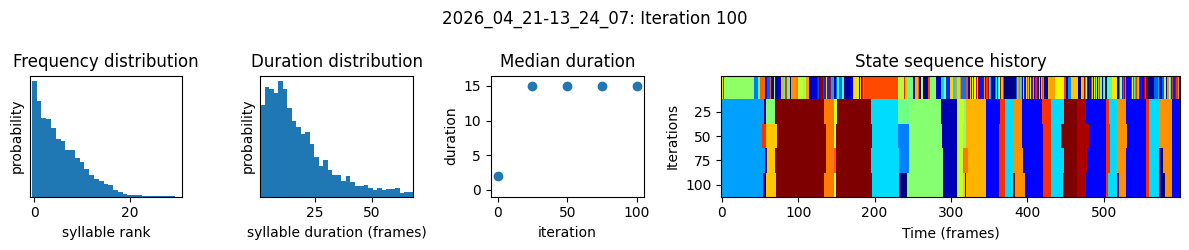

 23%|███████▍                         | 125/551 [04:24<14:49,  2.09s/it]

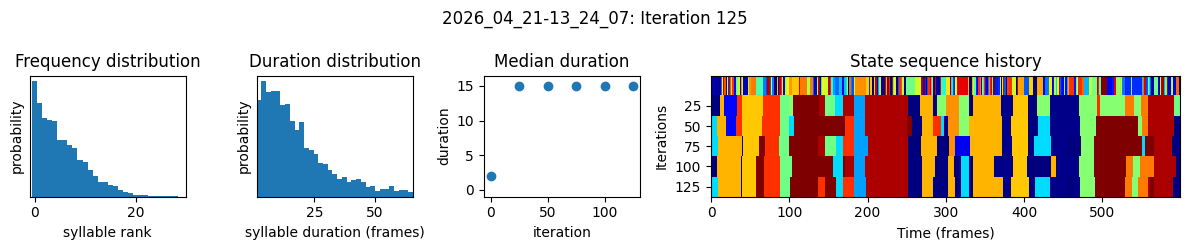

 27%|████████▉                        | 150/551 [05:17<14:04,  2.11s/it]

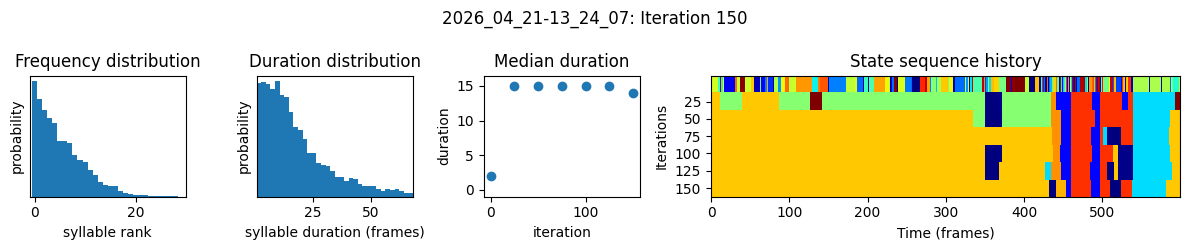

 32%|██████████▍                      | 175/551 [06:10<13:18,  2.12s/it]

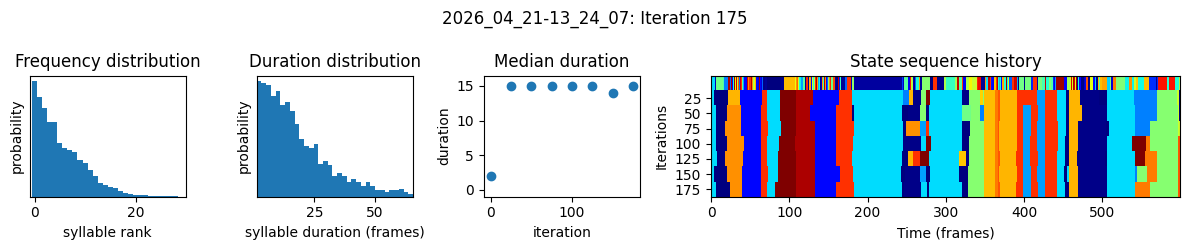

 36%|███████████▉                     | 200/551 [07:03<12:17,  2.10s/it]

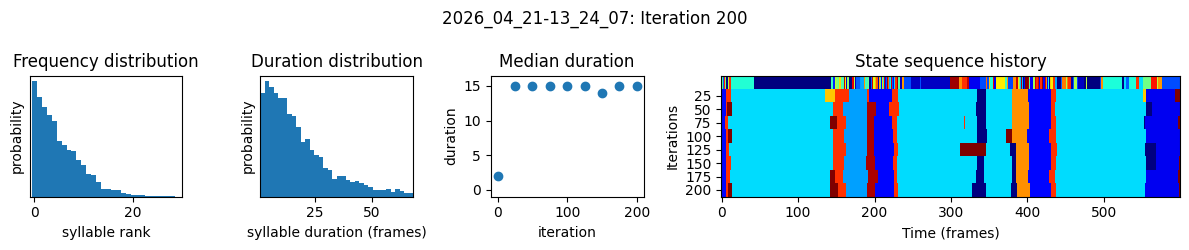

 41%|█████████████▍                   | 225/551 [07:56<11:29,  2.12s/it]

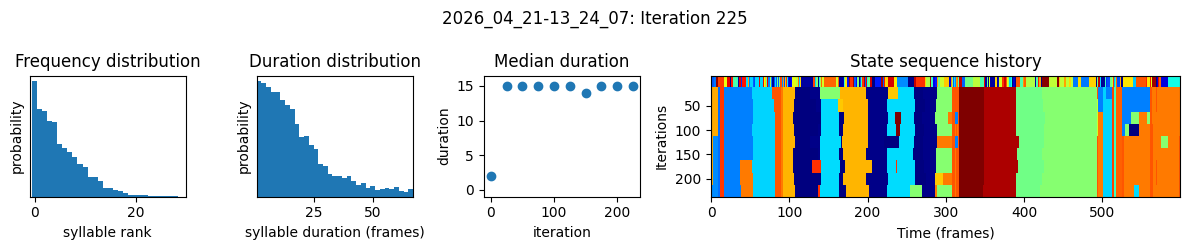

 45%|██████████████▉                  | 250/551 [08:48<10:22,  2.07s/it]

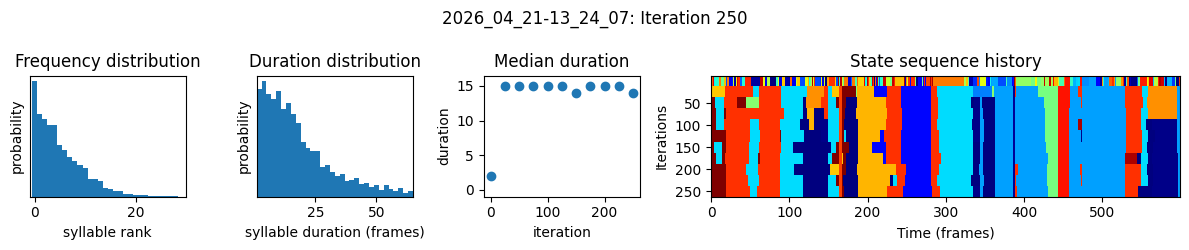

 50%|████████████████▍                | 275/551 [09:41<09:38,  2.10s/it]

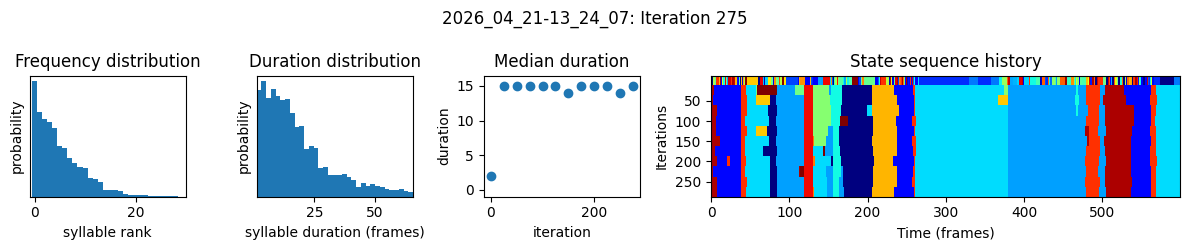

 54%|█████████████████▉               | 300/551 [10:34<08:47,  2.10s/it]

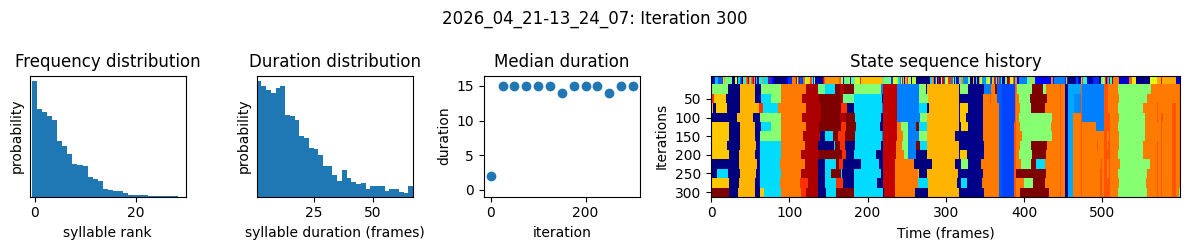

 59%|███████████████████▍             | 325/551 [11:27<07:51,  2.09s/it]

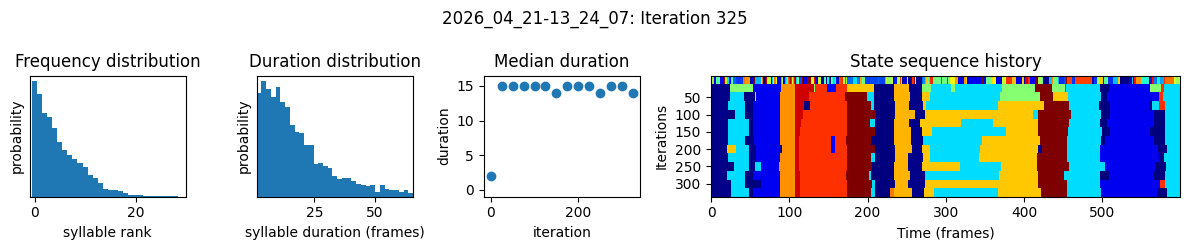

 64%|████████████████████▉            | 350/551 [12:20<07:00,  2.09s/it]

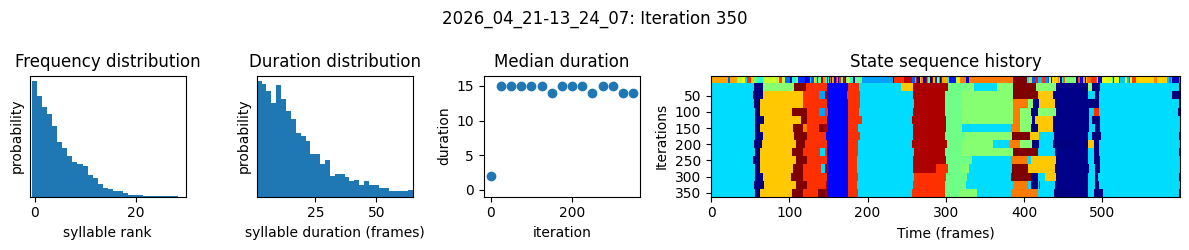

 68%|██████████████████████▍          | 375/551 [13:12<06:07,  2.09s/it]

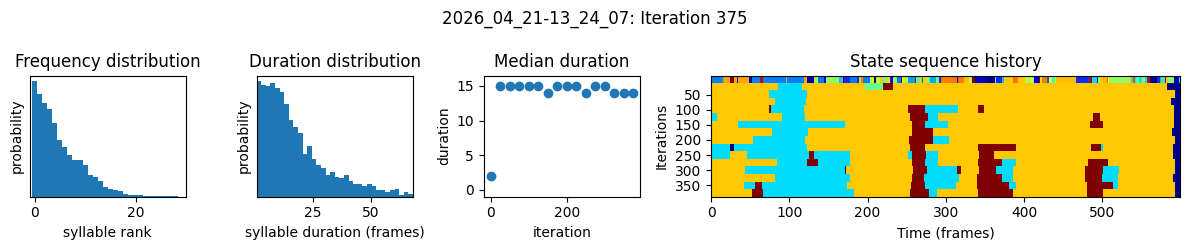

 73%|███████████████████████▉         | 400/551 [14:05<05:11,  2.06s/it]

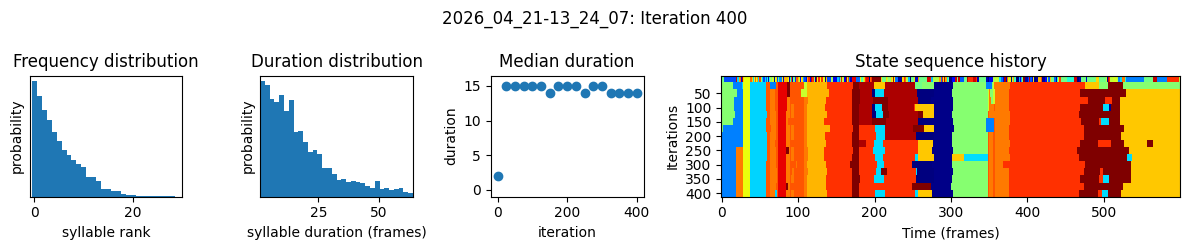

 77%|█████████████████████████▍       | 425/551 [14:57<04:25,  2.11s/it]

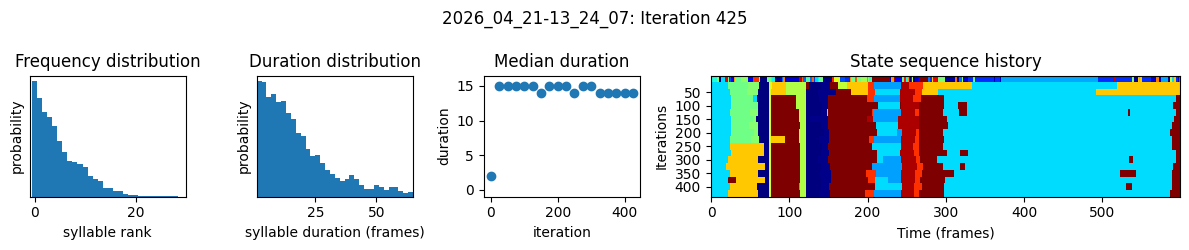

 82%|██████████████████████████▉      | 450/551 [15:50<03:40,  2.19s/it]

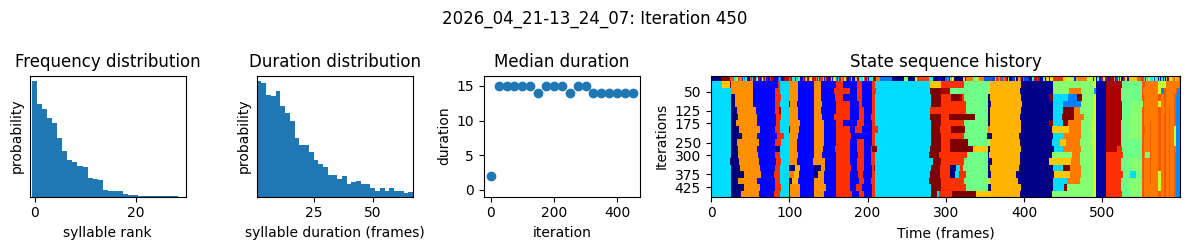

 86%|████████████████████████████▍    | 475/551 [16:44<02:38,  2.08s/it]

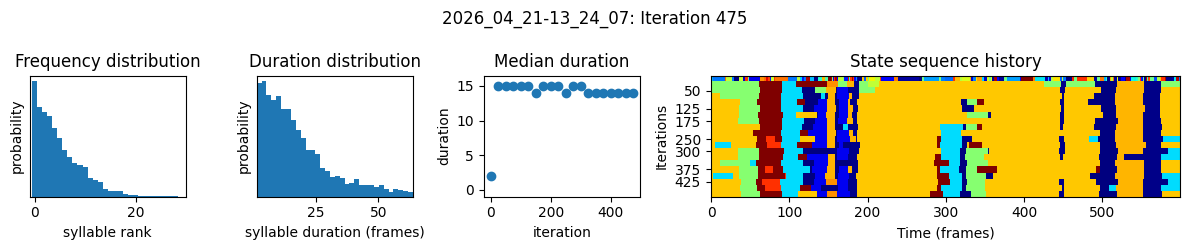

 91%|█████████████████████████████▉   | 500/551 [17:36<01:45,  2.06s/it]

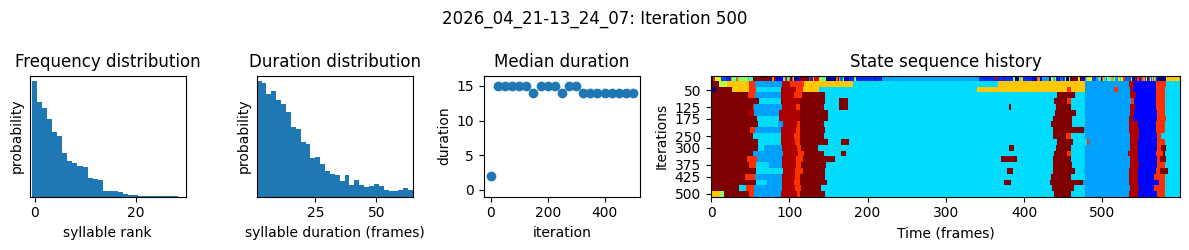

 95%|███████████████████████████████▍ | 525/551 [18:27<00:52,  2.04s/it]

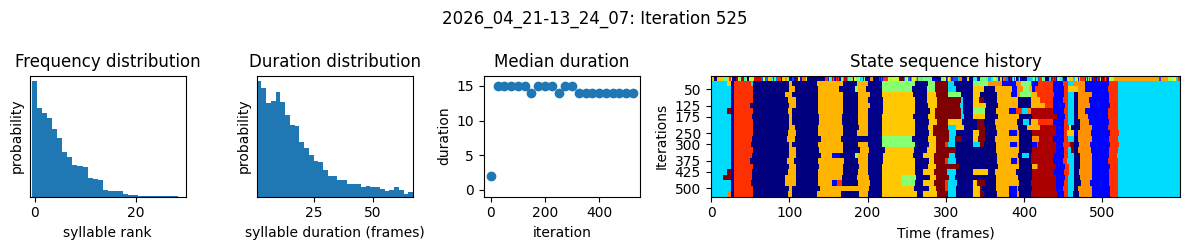

100%|████████████████████████████████▉| 550/551 [19:19<00:02,  2.04s/it]

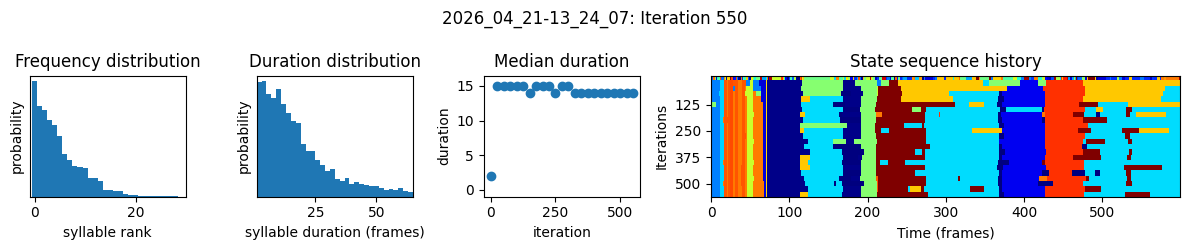

100%|█████████████████████████████████| 551/551 [19:21<00:00,  2.11s/it]


In [60]:

# load model checkpoint
model, data, metadata, current_iter = kpms.load_checkpoint(
    project_dir, model_name, iteration=num_ar_iters
)
# modify kappa to maintain the desired syllable time-scale
model = kpms.update_hypparams(model, kappa=5e4)

# run fitting for an additional 500 iters
model = kpms.fit_model(
    model,
    data,
    metadata,
    project_dir,
    model_name,
    jitter=1e-2,
    ar_only=False,
    num_iters=current_iter+500
)

In [10]:
model_name = '2026_04_21-13_24_07'

In [11]:
# modify a saved checkpoint so syllables are ordered by frequency
kpms.reindex_syllables_in_checkpoint(project_dir, model_name);

Reindexing: 100%|███████████| 23/23 [00:00<00:00, 52.81model snapshot/s]


In [12]:
# load the most recent model checkpoint
model, data, metadata, current_iter = kpms.load_checkpoint(project_dir, model_name)

# extract results
results = kpms.extract_results(model, metadata, project_dir, model_name)

Saved results to /Users/ramzyalmulla/research/smearlab/keypoint_moseq_
2209_t7/2026_04_21-13_24_07/results.h5


Saving trajectory plots to /Users/ramzyalmulla/research/smearlab/keypoint_moseq_2209_t7/2026_04_21-13_24_07/trajectory_plots


Generating trajectory plots: 100%|██████| 14/14 [00:03<00:00,  4.50it/s]


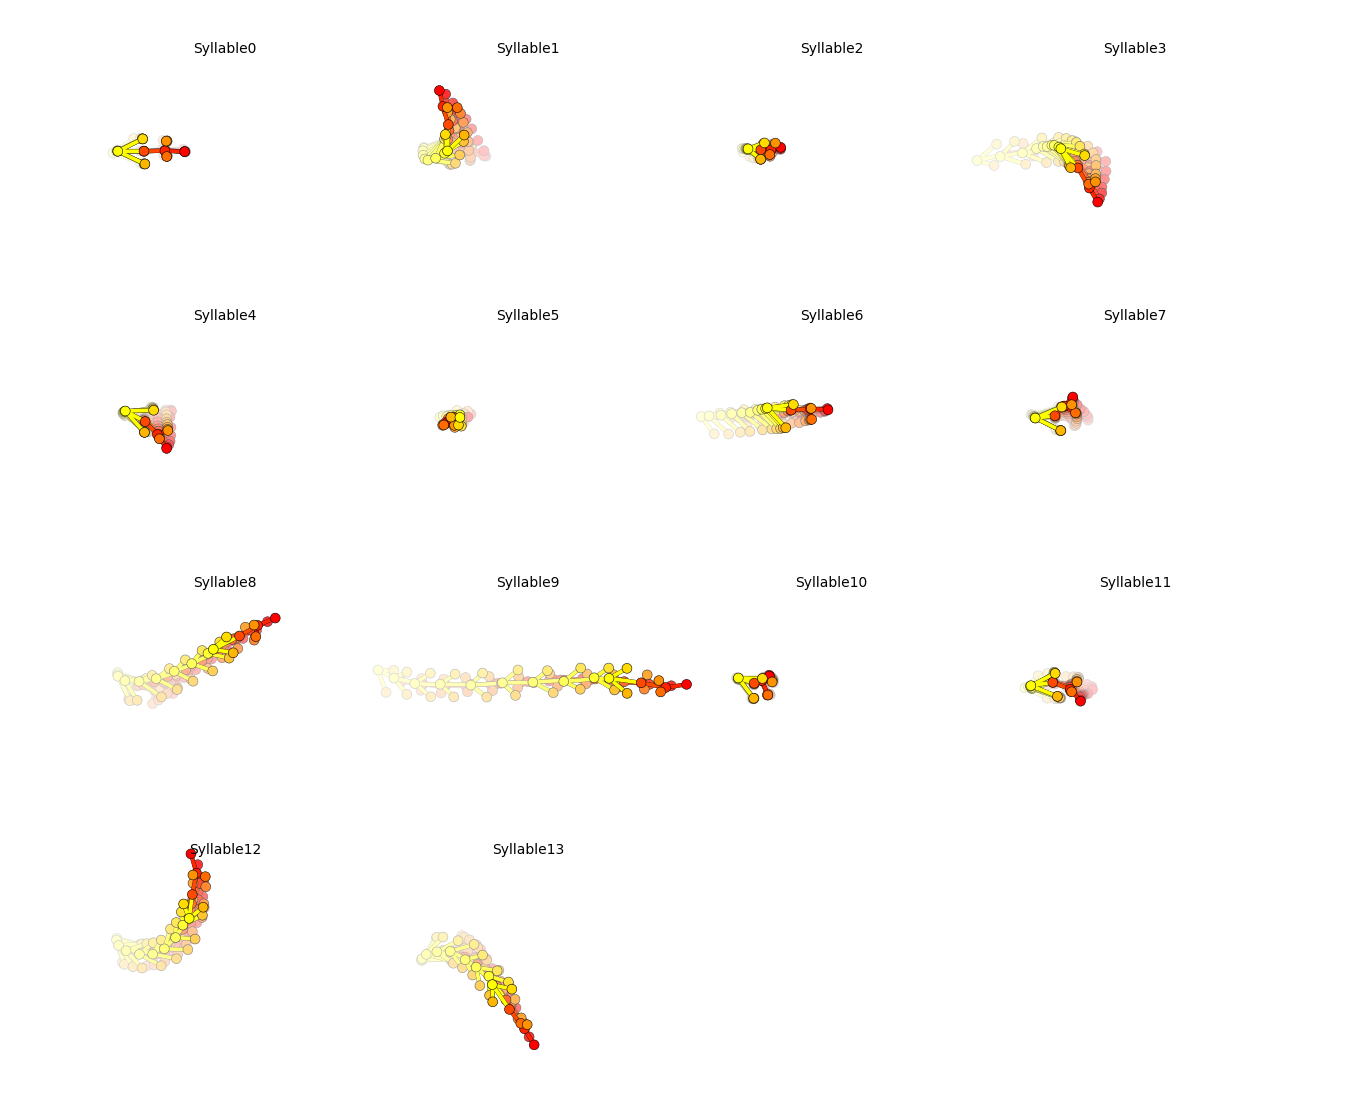

In [13]:
results = kpms.load_results(project_dir, model_name)
kpms.generate_trajectory_plots(coordinates, results, project_dir, model_name, **config())


Saving dendrogram plot to /Users/ramzyalmulla/research/smearlab/keypoint_moseq_2209_t7/2026_04_21-13_24_07/similarity_dendrogram


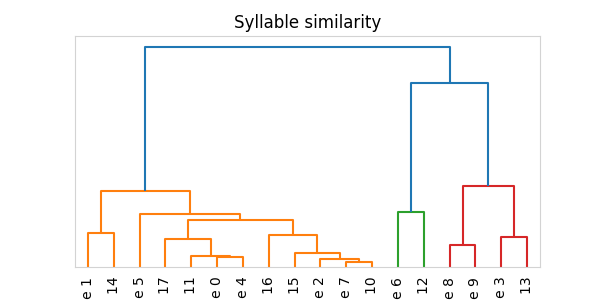

In [14]:
kpms.plot_similarity_dendrogram(coordinates, results, project_dir, model_name, **config())

In [18]:
kpms.generate_grid_movies(results, project_dir, model_name, 
                          coordinates=coordinates, overlay_keypoints=True, **config());

Writing grid movies to /Users/ramzyalmulla/research/smearlab/keypoint_moseq_2209_t7/2026_04_21-13_24_07/grid_movies



Videos will be downscaled by a factor of 0.57 so that the grid movies
are under 1920 pixels. Use `max_video_size` to increase or decrease
this size limit.



Using window size of 560 pixels


Generating grid movies: 100%|███████████| 17/17 [02:51<00:00, 10.08s/it]os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.


In [8]:
subject = '2209'
session = 't7'
modelFolder = "labels_v003_0.5scaling"
project_dir = str(Path(f"/Users/ramzyalmulla/research/smearlab/keypoint_moseq_{subject}_{session}/"))
model_name = "2026_04_21-13_24_07"
config = lambda: kpms.load_config(project_dir)

In [12]:
# load the most recent model checkpoint and pca object
model = kpms.load_checkpoint(project_dir, model_name)[0]

# load new data (e.g. from deeplabcut)
new_data = "/Users/ramzyalmulla/research/smearlab/sleap_preds_30fps/*[t7].slp"  # can be a file, a directory, or a list of files
coordinates, confidences, bodyparts = kpms.load_keypoints(new_data, "sleap")
coordinates, confidences = kpms.outlier_removal(
    coordinates,
    confidences,
    project_dir,
    overwrite=False,
    **config()
)


Loading keypoints: 100%|██████████████████| 3/3 [00:07<00:00,  2.33s/it]


In [13]:
data, metadata = kpms.format_data(coordinates, confidences, **config())
import jax_moseq
data = jax_moseq.utils.debugging.convert_data_precision(data)


# apply saved model to new data
results = kpms.apply_model(model, data, metadata, project_dir, model_name, overwrite=True,**config())

# if applying to data that includes the original training recordings,
# set overwrite=True to replace the existing results for those recordings
# results = kpms.apply_model(model, data, metadata, project_dir, model_name, overwrite=True, **config())

# optionally rerun `save_results_as_csv` to export the new results
# kpms.save_results_as_csv(results, project_dir, model_name)

Applying model: 100%|█████████████████| 500/500 [59:30<00:00,  7.14s/it]


AssertionError: 04182026_2209_t7 already exists in <HDF5 file "results.h5" (mode r+)>. Set overwrite to True to overwrite data in an existing file.

In [14]:
results

NameError: name 'results' is not defined